In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [156]:
df = pd.read_csv("data/player_data_COMPLETE.csv")

Filtramos para que nos salgan únicamente los jugadores de la posición que queremos

In [157]:
df_mf_todos = df[df["main_position"].isin(["MF", "DMF"])].copy()
df_clustering = df_mf_todos[df_mf_todos["low_minutes_flag"] == False].copy()

Selección de métricas

In [158]:
features_clustering = [
    
    # pase / control
    "passes_avg",
    "progressive_pass_avg",
    
    # creación
    "xg_assist_avg",
    "goals_avg",
    
    # progresión
    "real_progression",
    
    # defensa
    "interceptions_avg",
    "duels_won_avg"

]

X = df_clustering[features_clustering].fillna(0)

Escalado

In [159]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [160]:
df_scaled = pd.DataFrame(X_scaled, columns=features_clustering)
print("\nDatos estandarizados:")
print(df_scaled.head())


Datos estandarizados:
   passes_avg  progressive_pass_avg  xg_assist_avg  goals_avg  \
0    0.025475             -0.186141      -1.150029   0.170559   
1   -1.004925             -1.148710      -0.204456  -0.860273   
2   -0.238983              0.004140      -0.771800  -0.860273   
3    0.851135              0.375854      -0.771800  -0.860273   
4   -0.225918              0.020302      -0.204456  -0.159811   

   real_progression  interceptions_avg  duels_won_avg  
0         -0.552594           0.736506      -0.386011  
1         -0.876389          -0.094052       2.679265  
2          0.087472           1.564192       2.972066  
3          0.251328           1.037923      -0.079639  
4         -0.331808           0.025103       1.040362  


PCA: Reducción de dimensionalidad

In [161]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)

[0.43337086 0.19974878 0.14887975]


In [162]:
n_components = 3
pca_clustering = pd.DataFrame(data=X_pca, columns=[f'PC{i}' for i in range(1, n_components+1)])
print("\nComponentes principales:")
print(pca_clustering.head())


Componentes principales:
        PC1       PC2       PC3
0 -0.743142 -0.736761 -0.153906
1 -2.358632 -0.118062  1.194506
2 -1.297480 -2.007194  2.189303
3  0.308135 -1.724741 -0.179874
4 -0.619525 -0.196793  0.610461


C:\Users\Germán Llorente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Germán Llorente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Germán Llorente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the

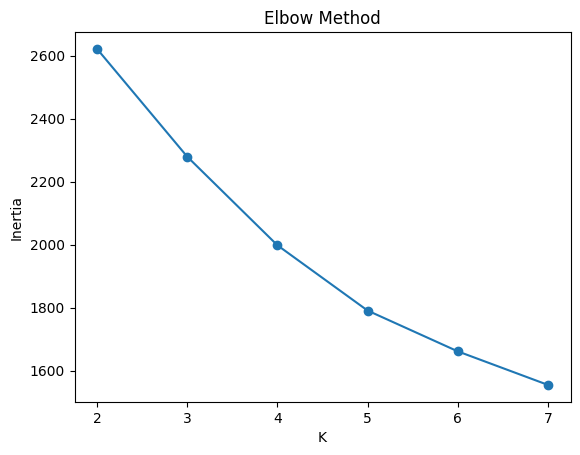

In [163]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

import matplotlib.pyplot as plt
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

In [164]:
kmeans = KMeans(n_clusters=4, random_state=42)
df_clustering["cb_cluster"] = kmeans.fit_predict(X_scaled)

C:\Users\Germán Llorente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [165]:
cluster_profile = df_clustering.groupby("cb_cluster")[features_clustering].mean()
print(cluster_profile)

            passes_avg  progressive_pass_avg  xg_assist_avg  goals_avg  \
cb_cluster                                                               
0            32.918200              4.227368       0.033907   0.037327   
1            44.881739              6.385241       0.046347   0.041196   
2            62.171859              8.894341       0.123431   0.085853   
3            39.364230              5.137445       0.093194   0.187449   

            real_progression  interceptions_avg  duels_won_avg  
cb_cluster                                                      
0                   5.110952           3.594557       8.202235  
1                   7.247910           4.175479       7.322843  
2                  10.471787           3.140281       6.161770  
3                   6.492700           2.912693       7.588565  


In [166]:
cols_show = ["name", "market_value", "minutes_on_field", "cb_cluster"]

df_cb_view = df_clustering[cols_show].sort_values(
    ["cb_cluster", "market_value"],
    ascending=[True, False]
)

for c in sorted(df_clustering["cb_cluster"].unique()):
    print(f"\n--- CLUSTER {c} ---")
    display(df_cb_view[df_cb_view["cb_cluster"] == c].head(10))


--- CLUSTER 0 ---


,name,market_value,minutes_on_field,cb_cluster
668,K. Mainoo,55000000.0,1410,0
2523,João Palhinha,55000000.0,1435,0
1649,A. Onana,50000000.0,1557,0
3398,M. Ugarte,45000000.0,1956,0
2750,Joelinton,40000000.0,2418,0
3229,B. Kamara,38000000.0,2692,0
1189,R. Lavia,35000000.0,651,0
1277,João Gomes,35000000.0,3246,0
3277,Y. Bissouma,35000000.0,1108,0
3320,D. Frattesi,35000000.0,963,0



--- CLUSTER 1 ---


,name,market_value,minutes_on_field,cb_cluster
3499,M. Hjulmand,40000000.0,2463,1
643,A. Varela,35000000.0,2308,1
3013,R. Bentancur,35000000.0,2013,1
3076,I. Sangaré,30000000.0,1069,1
3801,Y. Fofana,30000000.0,2780,1
2317,S. Lobotka,28000000.0,2682,1
2079,P. Zieliński,22000000.0,1026,1
2681,S. Amrabat,22000000.0,663,1
2961,Pepelu,22000000.0,1906,1
3045,V. Janelt,22000000.0,1705,1



--- CLUSTER 2 ---


,name,market_value,minutes_on_field,cb_cluster
1147,Pedri,80000000.0,2984,2
2488,Bruno Fernandes,70000000.0,3392,2
3073,F. de Jong,70000000.0,2038,2
2907,Fabián Ruiz,35000000.0,2023,2
2051,M. Kovačić,30000000.0,1523,2
2250,L. Goretzka,30000000.0,1894,2
2788,I. Bennacer,30000000.0,944,2
2693,M. Locatelli,28000000.0,2984,2
3834,O. Kökçü,27000000.0,1636,2
2658,Aleix García,25000000.0,2226,2



--- CLUSTER 3 ---


,name,market_value,minutes_on_field,cb_cluster
3097,D. Rice,120000000.0,3266,3
3061,Bruno Guimarães,85000000.0,3606,3
3583,A. Mac Allister,75000000.0,2788,3
2580,Bernardo Silva,70000000.0,2673,3
2668,J. Maddison,70000000.0,1239,3
1196,P. Sarr,45000000.0,2184,3
3479,C. Jones,35000000.0,1942,3
3833,K. Thuram,35000000.0,2775,3
3164,S. McTominay,32000000.0,3254,3
2202,J. Ward-Prowse,30000000.0,1675,3


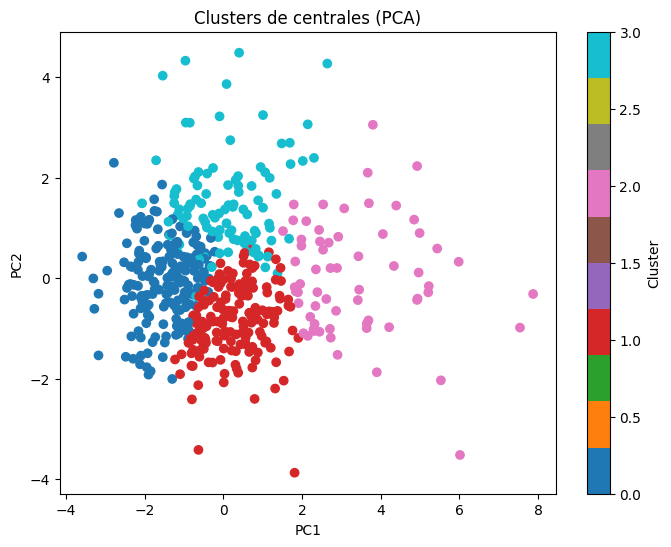

In [167]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df_clustering["cb_cluster"],
    cmap="tab10"
)

plt.title("Clusters de centrales (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(label="Cluster")
plt.show()

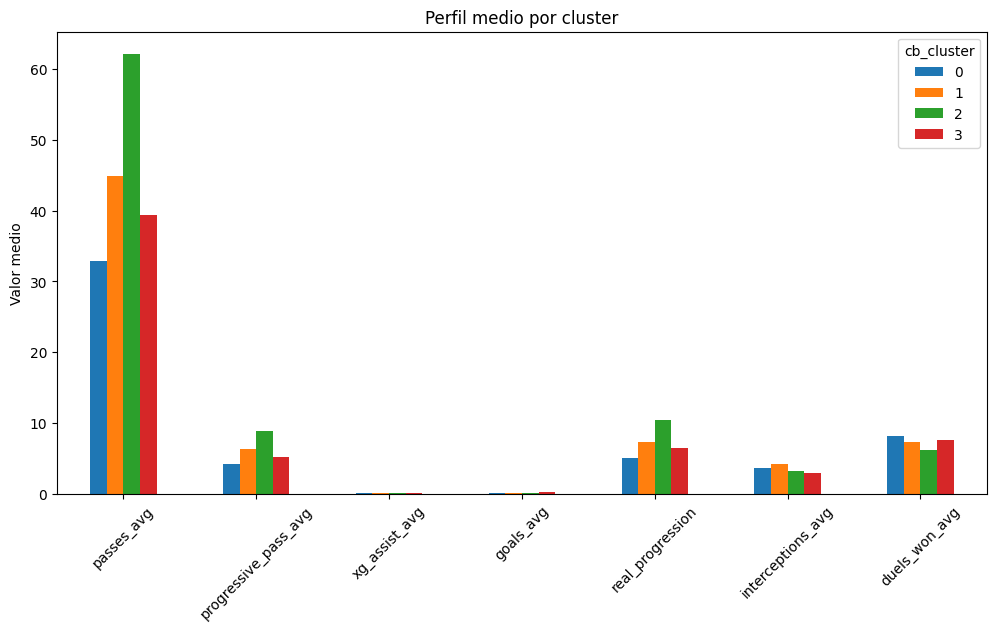

In [168]:
cluster_profile.T.plot(kind="bar", figsize=(12,6))
plt.title("Perfil medio por cluster")
plt.xticks(rotation=45)
plt.ylabel("Valor medio")
plt.show()

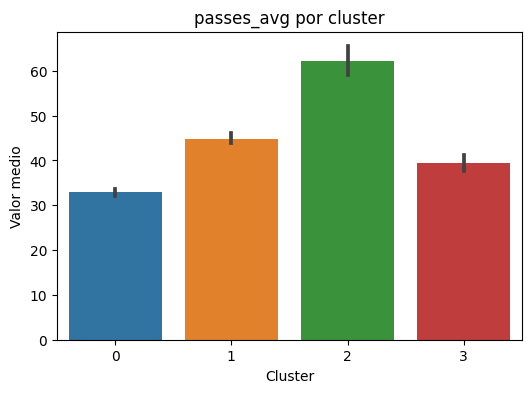

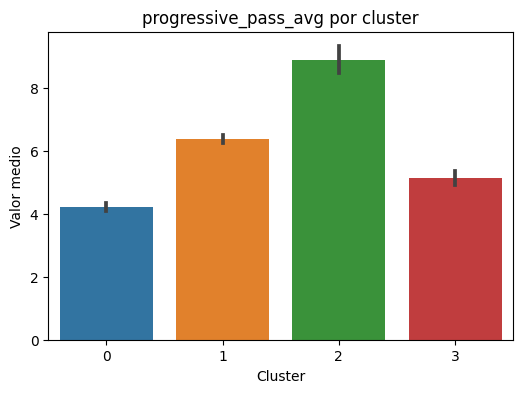

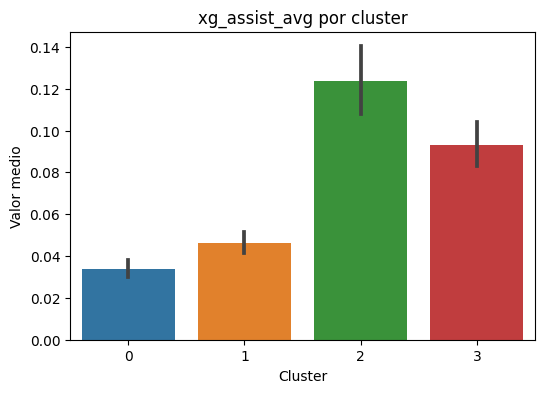

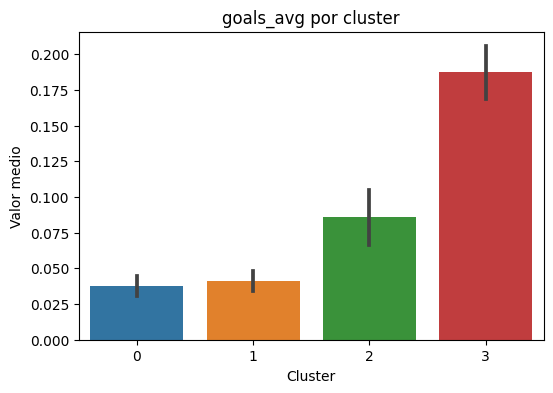

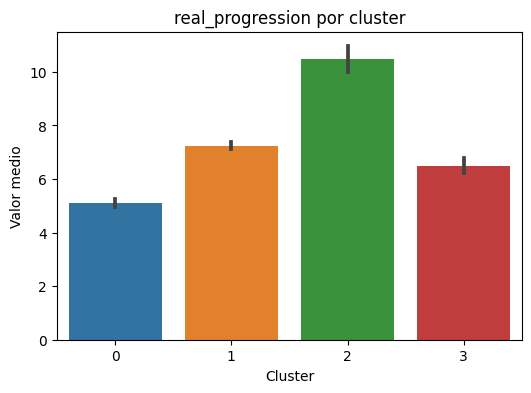

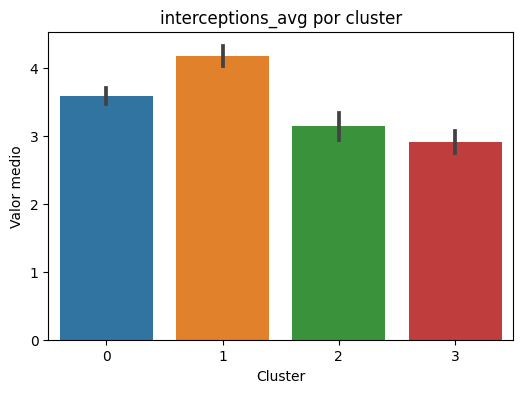

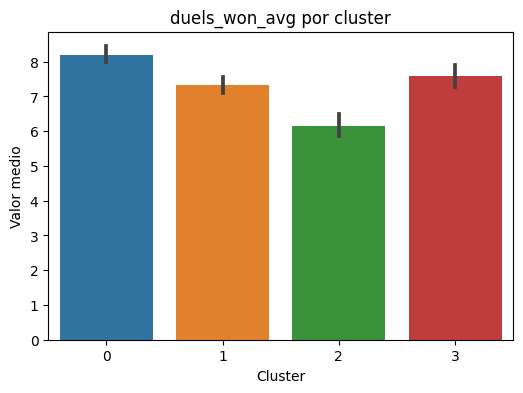

In [169]:
for col in features_clustering:
    
    plt.figure(figsize=(6,4))
    
    sns.barplot(
        x="cb_cluster",
        y=col,
        data=df_clustering
    )
    
    plt.title(f"{col} por cluster")
    plt.xlabel("Cluster")
    plt.ylabel("Valor medio")
    
    plt.show()

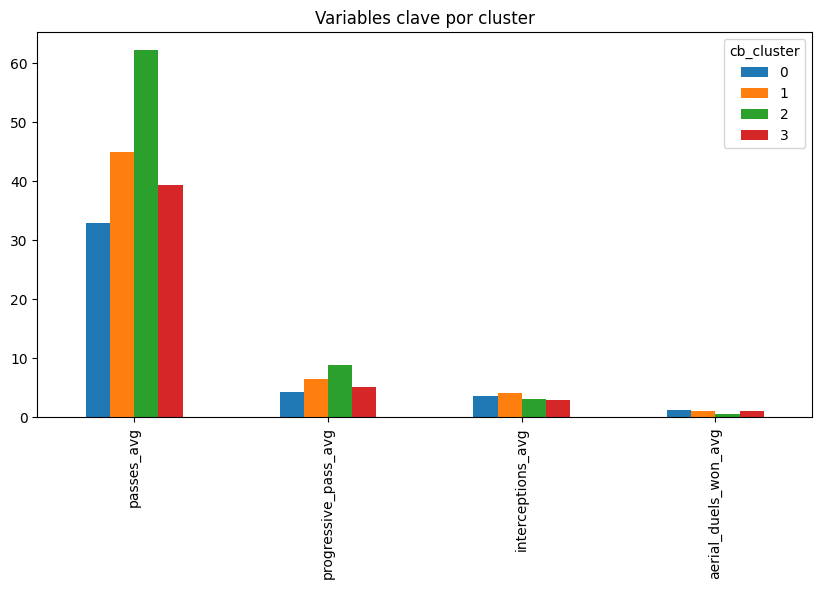

In [170]:
key_vars = [
    "passes_avg",
    "progressive_pass_avg",
    "interceptions_avg",
    "aerial_duels_won_avg"
]

df_clustering.groupby("cb_cluster")[key_vars].mean().T.plot(kind="bar", figsize=(10,5))
plt.title("Variables clave por cluster")
plt.show()

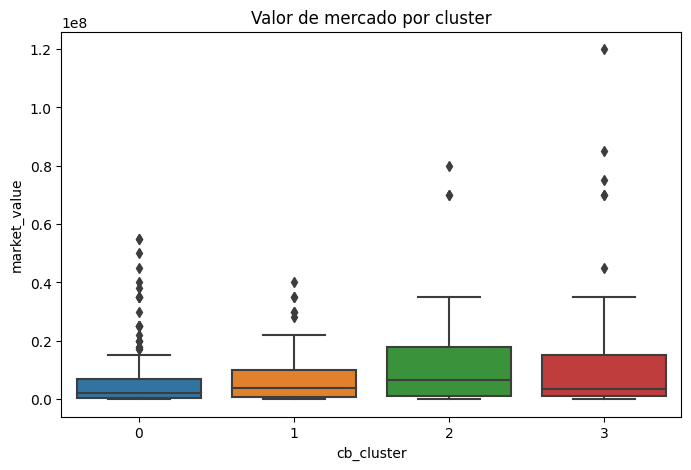

In [171]:
plt.figure(figsize=(8,5))
sns.boxplot(x="cb_cluster", y="market_value", data=df_clustering)
plt.title("Valor de mercado por cluster")
plt.show()

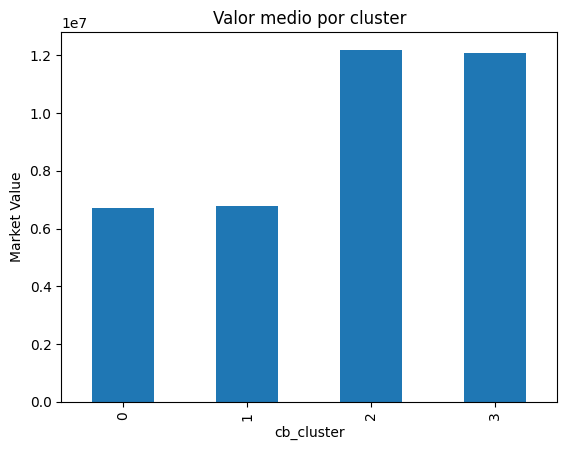

In [172]:
df_clustering.groupby("cb_cluster")["market_value"].mean().plot(kind="bar")

plt.title("Valor medio por cluster")
plt.ylabel("Market Value")
plt.show()

In [173]:
loadings = pd.DataFrame(
    pca.components_,
    columns=features_clustering,
    index=["PC1", "PC2", "PC3"]
)

display(loadings)

,passes_avg,progressive_pass_avg,xg_assist_avg,goals_avg,real_progression,interceptions_avg,duels_won_avg
PC1,0.488640,0.520907,0.342903,0.101838,0.541419,-0.102689,-0.241358
PC2,-0.168572,-0.256295,0.441482,0.527794,-0.137419,-0.637903,-0.081362
PC3,-0.031886,0.109015,0.136872,0.536206,0.129619,0.383365,0.719082


cluster_labels = {
    0: "Ball-winning midfielder",
    1: "Box-to-box midfielder",
    2: "Deep-lying playmaking midfielder",
    3: "Scoring midfielder"
}


In [174]:
cb_labels = {
    0: "Ball-stealing CB",
    1: "Ball-playing CB",
    2: "Aerial dominant CB",
    3: "Low-impact CB"
}

fb_labels = {
    0: "Attacking full-back",
    1: "Creative full-back",
    2: "Low-impact full-back",
    3: "Defensive full-back"
}

mf_labels = {
    0: "Ball-winning midfielder",
    1: "Box-to-box midfielder",
    2: "Deep-lying playmaking midfielder",
    3: "Scoring midfielder"
}

w_labels = {
    0: "Dribbler winger",
    1: "Low-impact winger",
    2: "Defensive winger",
    3: "Goal-scoring winger"
}

fw_labels = {
    0: "Target man",
    1: "Pressing forward",
    2: "Creative forward",
    3: "Poacher"
}

gk_labels = {
    0: "Low-performing GK",
    1: "Shot-stopper GK",
    2: "Ball-playing GK",
    3: "Low-impact GK"
}

def assign_role(row):
  
    return mf_labels.get(row["cb_cluster"])


df_clustering["player_role"] = df_clustering.apply(assign_role, axis=1)

In [175]:
df_clustering[["id", "name", "cb_cluster", "player_role"]].to_csv("clustering/data/mf_clusters.csv", index=False)